# Recommender Systems

### From Clustering to Personalization

In this lecture, we'll see how the concepts from our previous sessions — **similarity metrics**, **clustering**, and **dimensionality reduction** — come together to power one of the most impactful applications of unsupervised learning: **recommender systems**.

## Why Recommender Systems Matter

Every major digital platform relies on recommendations:

| Platform | What they recommend | Business impact |
|----------|--------------------|-----------------|
| **Spotify** | Songs, playlists, artists | 30% of all streams from recommendations |
| **Netflix** | Movies, TV shows | 80% of watched content from recommendations |
| **Amazon** | Products | 35% of revenue from recommendations |
| **YouTube** | Videos | 70% of watch time from recommendations |

These systems solve the **paradox of choice**: with millions of options available, users need help finding what they'll actually enjoy.

---

## Why is this Unsupervised Learning?

We only observe:
- User A listened to songs X, Y, Z
- User B listened to songs Y, Z, W

Nobody tells us *why* users like certain songs. The system must **discover hidden patterns** on its own:
- Which users have similar tastes?
- Which songs share common characteristics?
- What are the underlying "factors" that explain preferences?

This is exactly what unsupervised learning does: **find structure in unlabeled data**.

## Learning Objectives

By the end of this lecture, you will be able to:
1. Build and analyze a **user-item matrix**
2. Implement **User-Based Collaborative Filtering**
3. Implement **Item-Based Collaborative Filtering**
4. Apply **Matrix Factorization** to discover latent factors
5. Understand the **Cold Start Problem** and solutions

---

## Our Running Example: Spotify

Spotify has 600+ million users and 100+ million songs. The core problem:

> "Which songs should we recommend to each user?"

We'll work with a simulated Spotify-like dataset throughout this lecture.

In [11]:
# Setup - Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print("✓ Libraries loaded")

✓ Libraries loaded


---

# The User-Item Matrix

## What is it?

The **user-item matrix** is the core data structure for recommender systems:

- Each **row** = one user
- Each **column** = one item (song, movie, product...)
- Each **cell** = how much that user interacted with that item

```
              Song_1  Song_2  Song_3  Song_4  Song_5
User_Alice      15      0       3       0       0
User_Bob         0      8       0      12       0
User_Carol       5      0       7       0       2
```

**Key observation**: Most cells are **zero** (empty). Alice hasn't listened to most songs. This is called **sparsity**.

On real Spotify: 600M users × 100M songs = 60,000,000,000,000,000 potential cells!

In [13]:
# Generate a realistic Spotify-like dataset

def generate_spotify_data(n_users=500, n_songs=1000, density=0.03):
    """
    Generates a simulated Spotify listening dataset.
    
    Returns:
        df: DataFrame with user_id, song_id, play_count
        users: list of user IDs
        songs: list of song IDs
    """
    users = [f'user_{i}' for i in range(n_users)]
    songs = [f'song_{i}' for i in range(n_songs)]
    
    # Create song popularity distribution (power law - few popular songs)
    song_popularity = np.random.pareto(1.5, n_songs)
    song_popularity = song_popularity / song_popularity.sum()
    
    # Generate interactions
    interactions = []
    avg_songs_per_user = int(n_songs * density)
    
    for user_idx, user in enumerate(users):
        # Each user listens to a random number of songs
        n_listened = int(np.random.exponential(avg_songs_per_user)) + 5
        n_listened = min(n_listened, n_songs)
        
        # Select songs (biased towards popular ones)
        listened_songs = np.random.choice(n_songs, size=n_listened, replace=False, p=song_popularity)
        
        for song_idx in listened_songs:
            # Play count follows log-normal distribution
            play_count = int(np.random.lognormal(2, 1.5)) + 1
            interactions.append({
                'user_id': user,
                'song_id': songs[song_idx],
                'play_count': play_count,
                'user_idx': user_idx,
                'song_idx': song_idx
            })
    
    df = pd.DataFrame(interactions)
    return df, users, songs

# Generate the data
df, users, songs = generate_spotify_data(n_users=500, n_songs=800)

print(f"Dataset Overview:")
print(f"  • Users: {len(users)}")
print(f"  • Songs: {len(songs)}")
print(f"  • Total interactions: {len(df):,}")
print(f"\nSample data:")
df.head()

Dataset Overview:
  • Users: 500
  • Songs: 800
  • Total interactions: 13,852

Sample data:


,user_id,song_id,play_count,user_idx,song_idx
0,user_0,song_157,2,0,157
1,user_0,song_522,17,0,522
2,user_0,song_531,3,0,531
3,user_0,song_441,6,0,441
4,user_0,song_720,8,0,720


In [14]:
# Build the User-Item Matrix

def build_user_item_matrix(df, n_users, n_songs):
    """Constructs the user-item matrix from interaction data."""
    R = np.zeros((n_users, n_songs))
    for _, row in df.iterrows():
        R[row['user_idx'], row['song_idx']] = row['play_count']
    return R

R = build_user_item_matrix(df, len(users), len(songs))

# Calculate sparsity
n_interactions = np.count_nonzero(R)
total_cells = R.size
sparsity = 1 - (n_interactions / total_cells)

print(f"User-Item Matrix:")
print(f"  • Shape: {R.shape}")
print(f"  • Non-zero cells: {n_interactions:,}")
print(f"  • Total cells: {total_cells:,}")
print(f"  • Sparsity: {sparsity:.1%} of cells are empty")

User-Item Matrix:
  • Shape: (500, 800)
  • Non-zero cells: 13,852
  • Total cells: 400,000
  • Sparsity: 96.5% of cells are empty


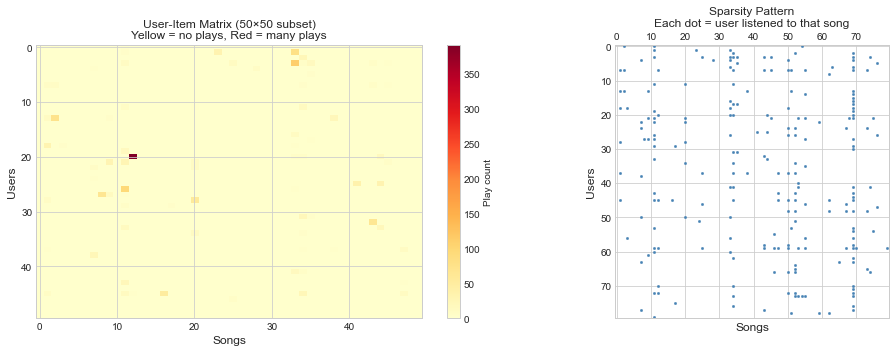


→ Notice how most of the matrix is empty (yellow/white).
   The goal: predict what goes in the empty cells!


In [15]:
# Visualize the matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Heatmap (first 50 users × 50 songs)
ax1 = axes[0]
im = ax1.imshow(R[:50, :50], aspect='auto', cmap='YlOrRd')
ax1.set_xlabel('Songs', fontsize=12)
ax1.set_ylabel('Users', fontsize=12)
ax1.set_title('User-Item Matrix (50×50 subset)\nYellow = no plays, Red = many plays', fontsize=12)
plt.colorbar(im, ax=ax1, label='Play count')

# Right: Sparsity pattern (dots where there's data)
ax2 = axes[1]
ax2.spy(R[:80, :80] > 0, markersize=1.5, color='steelblue')
ax2.set_xlabel('Songs', fontsize=12)
ax2.set_ylabel('Users', fontsize=12)
ax2.set_title('Sparsity Pattern\nEach dot = user listened to that song', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\n→ Notice how most of the matrix is empty (yellow/white).")
print(f"   The goal: predict what goes in the empty cells!")

---

# Implicit vs Explicit Feedback

## Explicit Feedback

Users **directly tell us** what they like:
- ⭐ Star ratings (1-5 stars on Amazon, Netflix)
- 👍👎 Thumbs up/down (YouTube)
- 📝 Written reviews

**Advantage**: Clear, unambiguous signal  
**Problem**: Very few users bother to rate things

## Implicit Feedback

We **infer preferences** from user behavior:
- 🎵 Number of plays (Spotify)
- ⏱️ Watch time (YouTube, TikTok)
- 🖱️ Clicks, purchases, time on page

**Advantage**: Abundant data, collected passively  
**Problem**: Signal is noisy. Did they play that song 100 times because they love it, or because they fell asleep?

---

## Spotify Uses Implicit Feedback

Spotify doesn't ask you to rate songs. Instead, it tracks:
- How many times you played each song
- Did you skip it?
- Did you add it to a playlist?
- Did you save it to your library?

Our `play_count` is implicit feedback. Let's analyze its distribution:

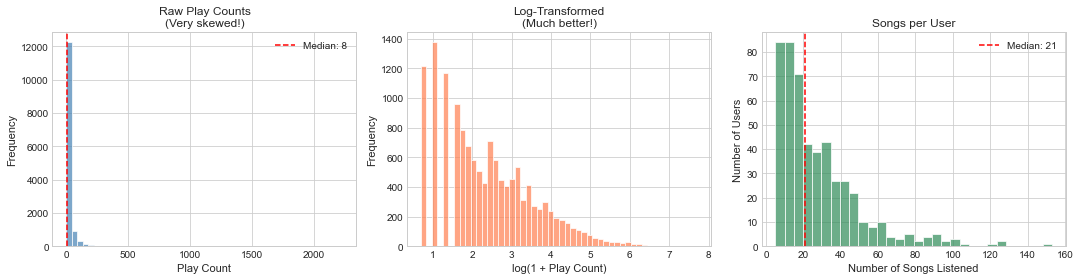

Play count statistics:
  • Mean: 23.3
  • Median: 8.0
  • Max: 2231

→ The distribution is heavily skewed. A few songs get played A LOT.


In [16]:
# Analyze the play count distribution

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

play_counts = df['play_count'].values

# 1. Raw distribution
ax1 = axes[0]
ax1.hist(play_counts, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
ax1.set_xlabel('Play Count', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Raw Play Counts\n(Very skewed!)', fontsize=12)
ax1.axvline(np.median(play_counts), color='red', linestyle='--', label=f'Median: {np.median(play_counts):.0f}')
ax1.legend()

# 2. Log-transformed
ax2 = axes[1]
log_plays = np.log1p(play_counts)  # log(1 + x) to handle zeros
ax2.hist(log_plays, bins=50, color='coral', edgecolor='white', alpha=0.7)
ax2.set_xlabel('log(1 + Play Count)', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Log-Transformed\n(Much better!)', fontsize=12)

# 3. Songs per user
ax3 = axes[2]
songs_per_user = df.groupby('user_id').size()
ax3.hist(songs_per_user, bins=30, color='seagreen', edgecolor='white', alpha=0.7)
ax3.set_xlabel('Number of Songs Listened', fontsize=11)
ax3.set_ylabel('Number of Users', fontsize=11)
ax3.set_title('Songs per User', fontsize=12)
ax3.axvline(songs_per_user.median(), color='red', linestyle='--', label=f'Median: {songs_per_user.median():.0f}')
ax3.legend()

plt.tight_layout()
plt.show()

print(f"Play count statistics:")
print(f"  • Mean: {play_counts.mean():.1f}")
print(f"  • Median: {np.median(play_counts):.1f}")
print(f"  • Max: {play_counts.max()}")
print(f"\n→ The distribution is heavily skewed. A few songs get played A LOT.")

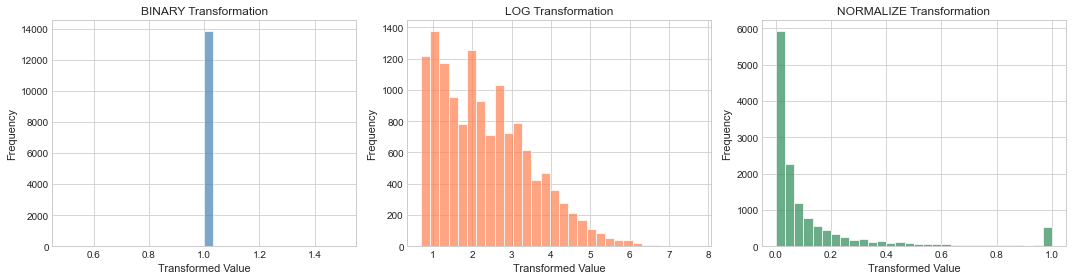


We'll use LOG transformation:
  • Original range: [0, 2231]
  • Log range: [0.00, 7.71]

→ Log compresses extreme values while preserving the preference ordering.


In [17]:
# Transform the matrix for better modeling

def transform_implicit_feedback(R, method='log'):
    """
    Transforms play counts to make them more suitable for modeling.
    
    Methods:
    - 'binary': Just 0 or 1 (did they listen or not?)
    - 'log': log(1 + x) to compress large values
    - 'normalize': Scale each user's values to 0-1
    """
    R_new = R.copy()
    
    if method == 'binary':
        R_new = (R > 0).astype(float)
        
    elif method == 'log':
        R_new = np.log1p(R)
        
    elif method == 'normalize':
        for i in range(R.shape[0]):
            if R[i].max() > 0:
                R_new[i] = R[i] / R[i].max()
    
    return R_new

# Compare transformations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

methods = ['binary', 'log', 'normalize']
colors = ['steelblue', 'coral', 'seagreen']

for idx, (method, color) in enumerate(zip(methods, colors)):
    R_t = transform_implicit_feedback(R, method=method)
    nonzero_vals = R_t[R_t > 0].flatten()
    
    axes[idx].hist(nonzero_vals, bins=30, color=color, edgecolor='white', alpha=0.7)
    axes[idx].set_xlabel(f'Transformed Value', fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'{method.upper()} Transformation', fontsize=12)

plt.tight_layout()
plt.show()

# Use log transformation going forward
R_log = transform_implicit_feedback(R, method='log')

print(f"\nWe'll use LOG transformation:")
print(f"  • Original range: [{R.min():.0f}, {R.max():.0f}]")
print(f"  • Log range: [{R_log.min():.2f}, {R_log.max():.2f}]")
print(f"\n→ Log compresses extreme values while preserving the preference ordering.")

---

#  Collaborative Filtering

## The Core Idea

Collaborative filtering is based on a simple intuition:

> "People who agreed in the past will agree in the future."

If Alice and Bob both love Arctic Monkeys and Taylor Swift, and Alice also loves Dua Lipa, then Bob will probably like Dua Lipa too.

**This is unsupervised** because:
- We don't have labels saying "Bob will like Dua Lipa"
- We discover patterns from the raw listening data
- The algorithm finds "similar users" without being told what "similar" means

## Two Approaches

| Approach | How it works | Best when |
|----------|--------------|----------|
| **User-Based CF** | Find similar users → recommend their favorites | Fewer users than items |
| **Item-Based CF** | Find similar items → recommend based on your history | Fewer items than users |

## User-Based Collaborative Filtering

### The Algorithm

1. **Build user vectors**: Each user is represented by their play counts
2. **Calculate similarity**: Use cosine similarity between user vectors
3. **Find neighbors**: Identify the k most similar users
4. **Predict ratings**: Weighted average of neighbors' preferences

### The Math

**Cosine Similarity** between users $u$ and $v$:

$$\text{sim}(u, v) = \frac{\mathbf{r}_u \cdot \mathbf{r}_v}{\|\mathbf{r}_u\| \|\mathbf{r}_v\|}$$

**Predicted rating** for user $u$ on item $i$:

$$\hat{r}_{ui} = \frac{\sum_{v \in N(u)} \text{sim}(u,v) \cdot r_{vi}}{\sum_{v \in N(u)} |\text{sim}(u,v)|}$$

Where $N(u)$ is the set of k most similar users who have interacted with item $i$.

In [18]:
# Calculate User-User Similarity

print("Computing user-user similarity matrix...")
user_similarity = cosine_similarity(R_log)

# Set diagonal to 0 (a user shouldn't be similar to themselves)
np.fill_diagonal(user_similarity, 0)

print(f"\nUser Similarity Matrix:")
print(f"  • Shape: {user_similarity.shape}")
print(f"  • Value range: [{user_similarity.min():.4f}, {user_similarity.max():.4f}]")

Computing user-user similarity matrix...

User Similarity Matrix:
  • Shape: (500, 500)
  • Value range: [0.0000, 0.6485]


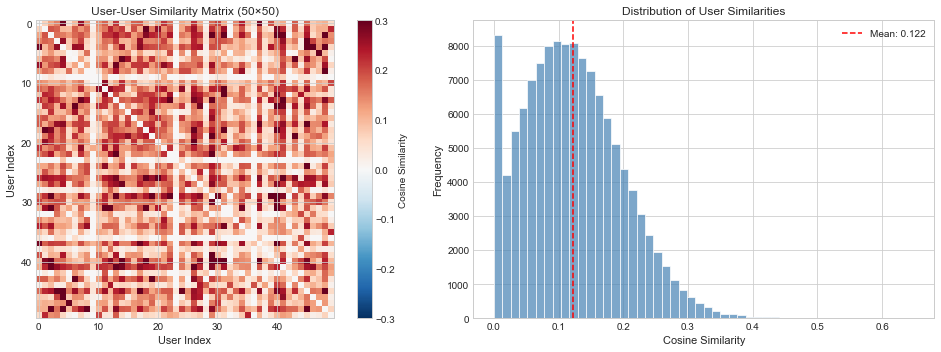


→ Most user pairs have low similarity (different tastes).
   A few pairs are quite similar — these become 'neighbors' for recommendations.


In [19]:
# Visualize User-User Similarity

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
ax1 = axes[0]
im = ax1.imshow(user_similarity[:50, :50], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
ax1.set_xlabel('User Index', fontsize=11)
ax1.set_ylabel('User Index', fontsize=11)
ax1.set_title('User-User Similarity Matrix (50×50)', fontsize=12)
plt.colorbar(im, ax=ax1, label='Cosine Similarity')

# Distribution of similarity values
ax2 = axes[1]
upper_tri = user_similarity[np.triu_indices(len(user_similarity), k=1)]
ax2.hist(upper_tri, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
ax2.set_xlabel('Cosine Similarity', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of User Similarities', fontsize=12)
ax2.axvline(upper_tri.mean(), color='red', linestyle='--', label=f'Mean: {upper_tri.mean():.3f}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\n→ Most user pairs have low similarity (different tastes).")
print(f"   A few pairs are quite similar — these become 'neighbors' for recommendations.")

In [20]:
# User-Based Recommendations

def recommend_user_based(user_idx, R, user_sim, k=20, n_recs=10):
    """
    Recommend songs using User-Based Collaborative Filtering.
    
    Steps:
    1. Find the k most similar users
    2. Get songs they listened to that target user hasn't
    3. Score songs by weighted average of similar users' play counts
    """
    # Get similarity scores for this user
    similarities = user_sim[user_idx]
    
    # Find k most similar users
    top_k_users = np.argsort(similarities)[-k:]
    top_k_sims = similarities[top_k_users]
    
    # Songs the target user has already listened to
    listened = set(np.where(R[user_idx] > 0)[0])
    
    # Score each unheard song
    scores = {}
    for song_idx in range(R.shape[1]):
        if song_idx in listened:
            continue
        
        # Weighted average of similar users' ratings
        weighted_sum = 0
        sim_sum = 0
        
        for neighbor, sim in zip(top_k_users, top_k_sims):
            if R[neighbor, song_idx] > 0:
                weighted_sum += sim * R[neighbor, song_idx]
                sim_sum += sim
        
        if sim_sum > 0:
            scores[song_idx] = weighted_sum / sim_sum
    
    # Return top recommendations
    recommended = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n_recs]
    return recommended

In [21]:
# Demo: Get recommendations for a user

target_user = 42

print(f"{'='*60}")
print(f"👤 USER-BASED RECOMMENDATIONS for User {target_user}")
print(f"{'='*60}")

# Show what this user has listened to
user_songs = np.where(R[target_user] > 0)[0]
user_plays = [(songs[s], R[target_user, s]) for s in user_songs]
user_plays = sorted(user_plays, key=lambda x: x[1], reverse=True)[:5]

print(f"\n🎵 Top songs this user has listened to:")
for song, plays in user_plays:
    print(f"   {song}: {int(plays)} plays")

# Find similar users
similar_users = np.argsort(user_similarity[target_user])[-5:]
print(f"\n👥 Most similar users:")
for u in similar_users[::-1]:
    print(f"   User {u}: similarity = {user_similarity[target_user, u]:.4f}")

# Get recommendations
recommendations = recommend_user_based(target_user, R_log, user_similarity, k=30, n_recs=10)

print(f"\n🎧 RECOMMENDED SONGS:")
for song_idx, score in recommendations:
    print(f"   {songs[song_idx]}: score = {score:.3f}")

👤 USER-BASED RECOMMENDATIONS for User 42

🎵 Top songs this user has listened to:
   song_431: 13 plays
   song_688: 9 plays
   song_112: 7 plays
   song_532: 7 plays
   song_174: 5 plays

👥 Most similar users:
   User 193: similarity = 0.3043
   User 191: similarity = 0.2901
   User 202: similarity = 0.2568
   User 57: similarity = 0.2145
   User 446: similarity = 0.2122

🎧 RECOMMENDED SONGS:
   song_727: score = 5.501
   song_416: score = 5.425
   song_762: score = 5.416
   song_552: score = 5.231
   song_223: score = 4.934
   song_302: score = 4.796
   song_483: score = 4.675
   song_279: score = 4.605
   song_776: score = 4.605
   song_437: score = 4.573


---

##  Item-Based Collaborative Filtering

Instead of finding similar users, we find **similar items** based on who listened to them.

### Why Item-Based is Often Preferred

| Factor | User-Based | Item-Based |
|--------|------------|------------|
| **Stability** | Users change preferences | Songs don't change |
| **Scalability** | O(n_users²) | O(n_items²), often smaller |
| **Explainability** | "Users like you..." | "Because you listened to X" ✓ |

**Amazon's famous insight**: "Customers who bought X also bought Y"

In [22]:
# Calculate Item-Item Similarity

print("Computing item-item similarity matrix...")
# Transpose: each song becomes a row (vector of user play counts)
item_similarity = cosine_similarity(R_log.T)

np.fill_diagonal(item_similarity, 0)

print(f"\nItem Similarity Matrix:")
print(f"  • Shape: {item_similarity.shape}")
print(f"  • Value range: [{item_similarity.min():.4f}, {item_similarity.max():.4f}]")

Computing item-item similarity matrix...

Item Similarity Matrix:
  • Shape: (800, 800)
  • Value range: [0.0000, 1.0000]


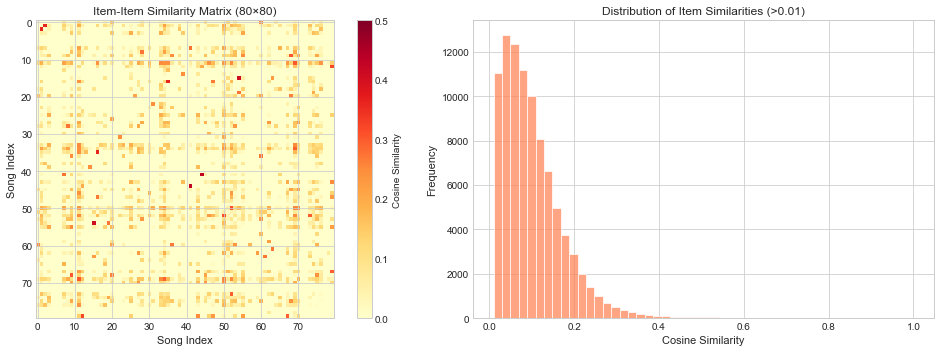

In [23]:
# Visualize Item-Item Similarity

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
ax1 = axes[0]
im = ax1.imshow(item_similarity[:80, :80], cmap='YlOrRd', vmin=0, vmax=0.5)
ax1.set_xlabel('Song Index', fontsize=11)
ax1.set_ylabel('Song Index', fontsize=11)
ax1.set_title('Item-Item Similarity Matrix (80×80)', fontsize=12)
plt.colorbar(im, ax=ax1, label='Cosine Similarity')

# Distribution
ax2 = axes[1]
upper_tri_items = item_similarity[np.triu_indices(len(item_similarity), k=1)]
nonzero = upper_tri_items[upper_tri_items > 0.01]
ax2.hist(nonzero, bins=50, color='coral', edgecolor='white', alpha=0.7)
ax2.set_xlabel('Cosine Similarity', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of Item Similarities (>0.01)', fontsize=12)

plt.tight_layout()
plt.show()

In [25]:
# Find similar songs to a given song

def get_similar_songs(song_idx, item_sim, n=10):
    """Find the n most similar songs to a given song."""
    similarities = item_sim[song_idx]
    top_n = np.argsort(similarities)[-n:][::-1]
    return [(idx, similarities[idx]) for idx in top_n]

# Demo
sample_song = 15
similar_songs = get_similar_songs(sample_song, item_similarity, n=8)

print(f"🎵 Songs similar to '{songs[sample_song]}':")
print(f"{'='*50}")
for idx, sim in similar_songs:
    print(f"   {songs[idx]}: similarity = {sim:.4f}")

🎵 Songs similar to 'song_15':
   song_514: similarity = 0.8788
   song_578: similarity = 0.6156
   song_316: similarity = 0.5263
   song_566: similarity = 0.4956
   song_54: similarity = 0.4053
   song_450: similarity = 0.3219
   song_301: similarity = 0.3195
   song_212: similarity = 0.2967


In [26]:
# Item-Based Recommendations

def recommend_item_based(user_idx, R, item_sim, n_recs=10):
    """
    Recommend songs using Item-Based Collaborative Filtering.
    
    For each unheard song, calculate its similarity to songs the user has listened to.
    """
    # Songs the user has listened to
    listened = np.where(R[user_idx] > 0)[0]
    listened_set = set(listened)
    
    scores = {}
    
    for song_idx in range(R.shape[1]):
        if song_idx in listened_set:
            continue
        
        # Score = weighted sum of similarities to listened songs
        weighted_sum = 0
        sim_sum = 0
        
        for heard_song in listened:
            sim = item_sim[song_idx, heard_song]
            if sim > 0:
                weighted_sum += sim * R[user_idx, heard_song]
                sim_sum += sim
        
        if sim_sum > 0:
            scores[song_idx] = weighted_sum / sim_sum
    
    recommended = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n_recs]
    return recommended

In [27]:
# Compare User-Based vs Item-Based recommendations

target_user = 42

print(f"{'='*65}")
print(f"🔄 COMPARISON: User-Based vs Item-Based for User {target_user}")
print(f"{'='*65}")

# User-based
user_recs = recommend_user_based(target_user, R_log, user_similarity, k=30, n_recs=8)
print(f"\n👥 USER-BASED Recommendations:")
for song_idx, score in user_recs:
    print(f"   {songs[song_idx]}: {score:.3f}")

# Item-based
item_recs = recommend_item_based(target_user, R_log, item_similarity, n_recs=8)
print(f"\n🎵 ITEM-BASED Recommendations:")
for song_idx, score in item_recs:
    print(f"   {songs[song_idx]}: {score:.3f}")

# Check overlap
user_set = set([s[0] for s in user_recs])
item_set = set([s[0] for s in item_recs])
overlap = len(user_set & item_set)

print(f"\n📊 Overlap: {overlap} songs in common")

🔄 COMPARISON: User-Based vs Item-Based for User 42

👥 USER-BASED Recommendations:
   song_727: 5.501
   song_416: 5.425
   song_762: 5.416
   song_552: 5.231
   song_223: 4.934
   song_302: 4.796
   song_483: 4.675
   song_279: 4.605

🎵 ITEM-BASED Recommendations:
   song_561: 2.639
   song_26: 2.611
   song_741: 2.410
   song_670: 2.410
   song_181: 2.363
   song_368: 2.303
   song_105: 2.287
   song_657: 2.277

📊 Overlap: 0 songs in common


---

#  The Cold Start Problem ❄️

The **Achilles' heel** of collaborative filtering:

## User Cold Start
🆕 **New user** with no listening history → Can't find similar users → No personalization!

## Item Cold Start
🆕 **New song** with no plays → Can't calculate similarity → Never gets recommended!

---

## Real-World Solutions

| Strategy | How it works | Example |
|----------|--------------|--------|
| **Hybrid Systems** | Combine CF with content-based | Spotify uses audio features for new songs |
| **Onboarding** | Ask initial preferences | "What 3 artists do you like?" |
| **Popularity Fallback** | Show trending content | "Top 50 Today" for new users |
| **Demographics** | Use age, location | Spotify's age-based playlists |
| **Social Graph** | Import from friends | Facebook/Instagram recommendations |

### 💭 Think About It

Compare a new Spotify user on **Day 1** vs someone with **5 years** of history:

- **Day 1**: Generic playlists, top charts, "What genres do you like?"
- **Week 1**: Starting to learn from skips and replays
- **Month 1**: Discover Weekly becomes personalized
- **Year 5**: *Knows you better than you know yourself*

That progression is the cold start problem being gradually solved!

---

# Matrix Factorization 🏆

The technique that **won the Netflix Prize** ($1M, 2009).

## The Intuition

Instead of comparing users/items directly, we learn **latent factors** — hidden features that explain preferences:

**Song factors** might represent:
- How energetic the song is
- How acoustic vs electronic
- The mood/vibe

**User factors** represent preferences:
- How much they like energetic music
- Their preference for acoustic sounds
- What moods they prefer

🔑 **Key Point**: We don't define these factors — the algorithm *discovers* them from the data!

## The Math

We decompose the rating matrix $R$ into two smaller matrices:

$$R_{m \times n} \approx P_{m \times k} \times Q_{k \times n}^T$$

Where:
- $P$ = user factor matrix (each user = k numbers)
- $Q$ = item factor matrix (each song = k numbers)
- $k$ = number of latent factors (typically 20-200)

**Prediction**: $\hat{r}_{ui} = \mathbf{p}_u \cdot \mathbf{q}_i$

In [28]:
# Matrix Factorization using SVD

from scipy.sparse.linalg import svds

# Center the matrix (subtract row means)
user_means = R_log.mean(axis=1)
R_centered = R_log - user_means.reshape(-1, 1)

# Perform SVD
k = 50  # Number of latent factors
print(f"Performing SVD with k={k} latent factors...")

U, sigma, Vt = svds(csr_matrix(R_centered), k=k)

# Reconstruct predictions
sigma_diag = np.diag(sigma)
predicted = np.dot(np.dot(U, sigma_diag), Vt) + user_means.reshape(-1, 1)

print(f"\n✅ Matrix Factorization Complete!")
print(f"   • Original matrix: {R_log.shape}")
print(f"   • User factors (P): {U.shape}")
print(f"   • Item factors (Q): {Vt.T.shape}")
print(f"   • Number of latent factors: {k}")

Performing SVD with k=50 latent factors...

✅ Matrix Factorization Complete!
   • Original matrix: (500, 800)
   • User factors (P): (500, 50)
   • Item factors (Q): (800, 50)
   • Number of latent factors: 50


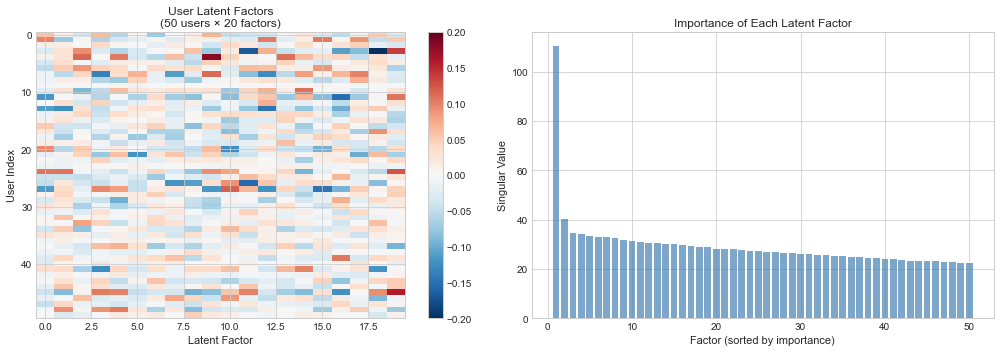


→ Each user is now represented by 50 'hidden' preferences
→ Top 3 factors explain 29.9% of the variance


In [29]:
# Visualize the latent factors

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# User factors
ax1 = axes[0]
im1 = ax1.imshow(U[:50, :20], cmap='RdBu_r', aspect='auto', vmin=-0.2, vmax=0.2)
ax1.set_xlabel('Latent Factor', fontsize=11)
ax1.set_ylabel('User Index', fontsize=11)
ax1.set_title('User Latent Factors\n(50 users × 20 factors)', fontsize=12)
plt.colorbar(im1, ax=ax1)

# Singular values
ax2 = axes[1]
ax2.bar(range(1, k+1), sigma[::-1], color='steelblue', alpha=0.7)
ax2.set_xlabel('Factor (sorted by importance)', fontsize=11)
ax2.set_ylabel('Singular Value', fontsize=11)
ax2.set_title('Importance of Each Latent Factor', fontsize=12)

plt.tight_layout()
plt.show()

# Variance explained
variance_explained = (sigma ** 2) / (sigma ** 2).sum()
top3 = variance_explained[::-1][:3].sum() * 100

print(f"\n→ Each user is now represented by {k} 'hidden' preferences")
print(f"→ Top 3 factors explain {top3:.1f}% of the variance")

In [30]:
# SVD-based recommendations

def recommend_svd(user_idx, predicted, R_original, n_recs=10):
    """Get recommendations from SVD predictions."""
    # Get predicted scores
    user_preds = predicted[user_idx]
    
    # Exclude songs already listened to
    listened = set(np.where(R_original[user_idx] > 0)[0])
    
    scores = [(i, user_preds[i]) for i in range(len(user_preds)) if i not in listened]
    return sorted(scores, key=lambda x: x[1], reverse=True)[:n_recs]

# Compare all three methods
target_user = 42

print(f"{'='*70}")
print(f"🎯 GRAND COMPARISON: All Methods for User {target_user}")
print(f"{'='*70}")

methods = [
    ("👥 USER-BASED", recommend_user_based(target_user, R_log, user_similarity, k=30, n_recs=5)),
    ("🎵 ITEM-BASED", recommend_item_based(target_user, R_log, item_similarity, n_recs=5)),
    ("🧮 MATRIX FACTORIZATION", recommend_svd(target_user, predicted, R, n_recs=5))
]

for name, recs in methods:
    print(f"\n{name}:")
    for song_idx, score in recs:
        print(f"   {songs[song_idx]}: {score:.3f}")

🎯 GRAND COMPARISON: All Methods for User 42

👥 USER-BASED:
   song_727: 5.501
   song_416: 5.425
   song_762: 5.416
   song_552: 5.231
   song_223: 4.934

🎵 ITEM-BASED:
   song_561: 2.639
   song_26: 2.611
   song_741: 2.410
   song_670: 2.410
   song_181: 2.363

🧮 MATRIX FACTORIZATION:
   song_154: 0.516
   song_411: 0.374
   song_522: 0.365
   song_498: 0.339
   song_1: 0.304


---

# Summary

## What We Covered

| Method | Key Idea | Pros | Cons |
|--------|----------|------|------|
| **User-Based CF** | Similar users → similar tastes | Serendipity | User cold start |
| **Item-Based CF** | Similar items | Stable, explainable | Item cold start |
| **Matrix Factorization** | Latent factors | Handles sparsity | Black box |

## Key Takeaways

1. **User-Item Matrix** is the fundamental data structure
2. **Implicit feedback** (plays, clicks) is more abundant but noisier than explicit ratings
3. **Log transformation** helps with skewed play count distributions
4. **Collaborative filtering** discovers patterns without labels (unsupervised!)
5. **Cold start** remains a major challenge
6. **Matrix factorization** won the Netflix Prize and remains powerful

---

---

## References

- **Koren, Y., Bell, R., & Volinsky, C.** (2009). Matrix Factorization Techniques for Recommender Systems. *IEEE Computer*.
- **Hu, Y., Koren, Y., & Volinsky, C.** (2008). Collaborative Filtering for Implicit Feedback Datasets. *ICDM*.
- **Spotify Engineering Blog**: https://engineering.atspotify.com/
- **Netflix Prize**: https://en.wikipedia.org/wiki/Netflix_Prize

---